In [3]:
from google.colab import files
uploaded = files.upload()

Saving 20191226-items.csv to 20191226-items.csv
Saving 20191226-reviews.csv to 20191226-reviews.csv


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [ ]:
# Step 0: Load datasets
import pandas as pd

# Use the actual file names for the files you uploaded
items = pd.read_csv("20191226-items.csv")
reviews = pd.read_csv("20191226-reviews.csv")

# Optional: Print the first few rows to confirm loading
print("Items DataFrame:")
print(items.head())
print("\nReviews DataFrame:")
print(reviews.head())

Items DataFrame:
         asin     brand                                              title  \
0  B0000SX2UC       NaN  Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...   
1  B0009N5L7K  Motorola                                Motorola I265 phone   
2  B000SKTZ0S  Motorola  MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...   
3  B001AO4OUC  Motorola              Motorola i335 Cell Phone Boost Mobile   
4  B001DCJAJG  Motorola      Motorola V365 no contract cellular phone AT&T   

                                                 url  \
0  https://www.amazon.com/Dual-Band-Tri-Mode-Acti...   
1  https://www.amazon.com/Motorola-i265-I265-phon...   
2  https://www.amazon.com/MOTOROLA-C168i-CINGULAR...   
3  https://www.amazon.com/Motorola-i335-Phone-Boo...   
4  https://www.amazon.com/Motorola-V365-contract-...   

                                               image  rating  \
0  https://m.media-amazon.com/images/I/2143EBQ210...     3.0   
1  https://m.media-amazon.com/images/I/419WBAVDAR

In [ ]:
# 0.1 Items overview
print("The dataset contains {0[0]: .0f} rows and {0[1]: .0f} variables.".format(items.shape))
items.head()

The dataset contains  720 rows and  10 variables.


,asin,brand,title,url,image,rating,reviewUrl,totalReviews,price,originalPrice
0,B0000SX2UC,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.00,0.0
1,B0009N5L7K,Motorola,Motorola I265 phone,https://www.amazon.com/Motorola-i265-I265-phon...,https://m.media-amazon.com/images/I/419WBAVDAR...,3.0,https://www.amazon.com/product-reviews/B0009N5L7K,7,49.95,0.0
2,B000SKTZ0S,Motorola,MOTOROLA C168i AT&T CINGULAR PREPAID GOPHONE C...,https://www.amazon.com/MOTOROLA-C168i-CINGULAR...,https://m.media-amazon.com/images/I/71b+q3ydkI...,2.7,https://www.amazon.com/product-reviews/B000SKTZ0S,22,99.99,0.0
3,B001AO4OUC,Motorola,Motorola i335 Cell Phone Boost Mobile,https://www.amazon.com/Motorola-i335-Phone-Boo...,https://m.media-amazon.com/images/I/710UO8gdT+...,3.3,https://www.amazon.com/product-reviews/B001AO4OUC,21,0.00,0.0
4,B001DCJAJG,Motorola,Motorola V365 no contract cellular phone AT&T,https://www.amazon.com/Motorola-V365-contract-...,https://m.media-amazon.com/images/I/61LYNCVrrK...,3.1,https://www.amazon.com/product-reviews/B001DCJAJG,12,149.99,0.0


In [ ]:
items.describe(include="all")

,asin,brand,title,url,image,rating,reviewUrl,totalReviews,price,originalPrice
count,720,716,720,720,720,720.000000,720,720.000000,720.000000,720.000000
unique,720,10,718,720,679,NaN,720,NaN,NaN,NaN
top,B07YZS6QT3,Samsung,"Apple iPhone 6S, 64GB, Rose Gold - For AT&T / ...",https://www.amazon.com/Samsung-A30S-Screen-Fin...,https://m.media-amazon.com/images/I/81yZOQEC+N...,NaN,https://www.amazon.com/product-reviews/B07YZS6QT3,NaN,NaN,NaN
freq,1,346,2,1,3,NaN,1,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,3.713750,NaN,105.679167,234.948931,63.690778
std,NaN,NaN,NaN,NaN,NaN,0.716014,NaN,167.601101,200.008441,172.405370
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,3.300000,NaN,7.000000,97.512500,0.000000
50%,NaN,NaN,NaN,NaN,NaN,3.800000,NaN,32.000000,188.975000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,4.100000,NaN,122.250000,336.725000,0.000000


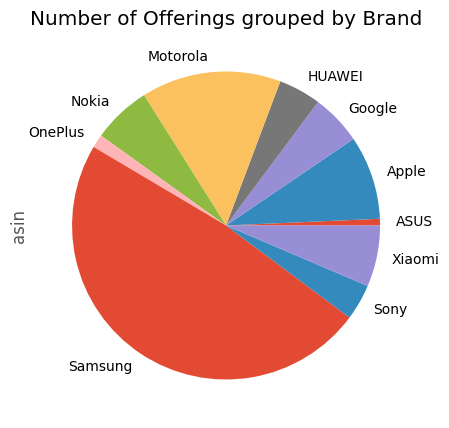

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
# Brand distribution
ax = items.groupby("brand").count()["asin"].plot(kind="pie",
                                                 figsize=(8, 5),
                                                 title="Number of Offerings grouped by Brand")
plt.show()

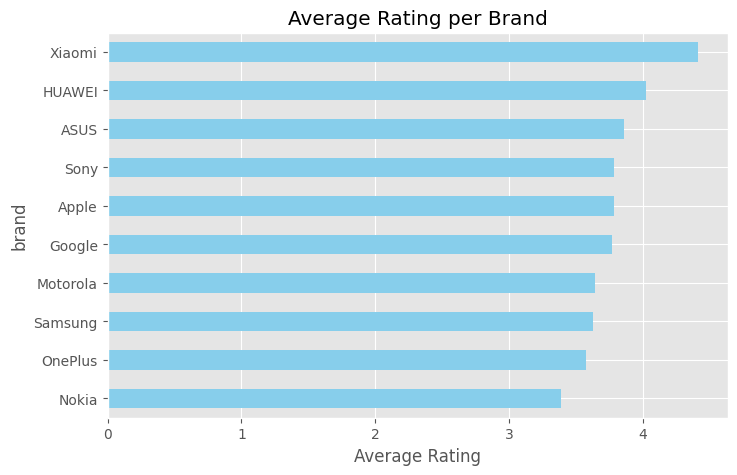

In [ ]:
# Average rating per brand
avg_rating = items.groupby("brand")["rating"].mean().sort_values()

ax = avg_rating.plot(kind="barh", figsize=(8,5), color="skyblue")
ax.set_title("Average Rating per Brand")
ax.set_xlabel("Average Rating")
plt.show()


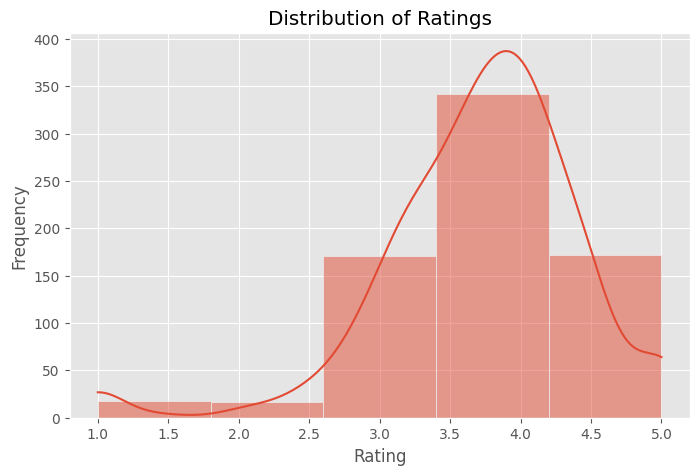

In [ ]:
# Distribution of ratings
plt.figure(figsize=(8, 5))
sns.histplot(items['rating'], bins=5, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# 0.2 Reviews overview
print("The dataset contains {0[0]: ,.0f} rows and {0[1]: .0f} variables.".format(reviews.shape))
reviews.head()

The dataset contains  67,986 rows and  8 variables.


,asin,name,rating,date,verified,title,body,helpfulVotes
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0


In [ ]:
# 0.4 Link review data to item data bsed on common column "asin"
reviews = pd.merge(reviews, items, how="left", left_on="asin", right_on="asin")

In [ ]:
# 0.5 Rename columns
reviews.rename(columns={"rating_x": "rating", "title_x": "title", "title_y": "item_title", "rating_y": "overall_rating"}, inplace=True)
reviews.head()

,asin,name,rating,date,verified,title,body,helpfulVotes,brand,item_title,url,image,overall_rating,reviewUrl,totalReviews,price,originalPrice
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.0,0.0
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.0,0.0
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.0,0.0
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.0,0.0
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0,NaN,Dual-Band / Tri-Mode Sprint PCS Phone w/ Voice...,https://www.amazon.com/Dual-Band-Tri-Mode-Acti...,https://m.media-amazon.com/images/I/2143EBQ210...,3.0,https://www.amazon.com/product-reviews/B0000SX2UC,14,0.0,0.0


In [ ]:
# 0.6 Convert string into datetime
from datetime import datetime
reviews["date"] = reviews["date"].apply(lambda x: datetime.strptime(x, '%B %d, %Y'))
reviews["date"].head()

,date
0,2005-10-11
1,2004-01-07
2,2003-12-30
3,2004-03-18
4,2005-08-28


In [ ]:
# 0.7 Truncate date column to month
reviews["month"] = reviews["date"].apply(lambda x: x.replace(day=1))
reviews["month"].head()

,month
0,2005-10-01
1,2004-01-01
2,2003-12-01
3,2004-03-01
4,2005-08-01


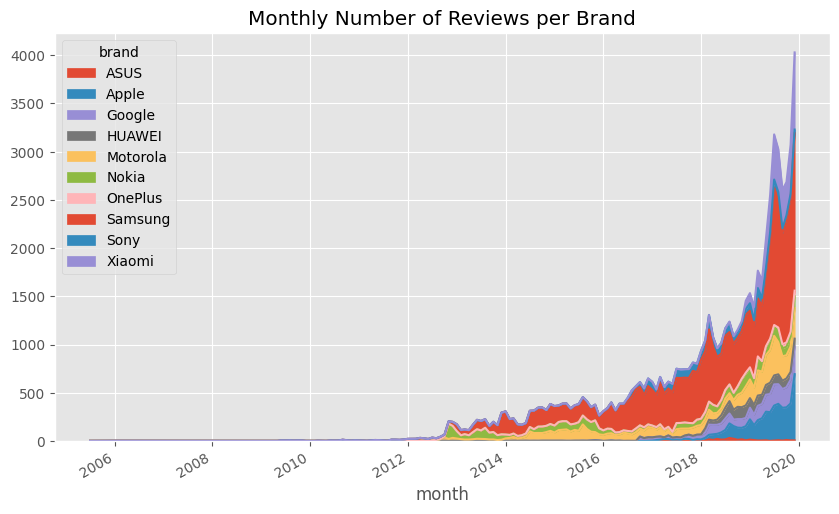

In [ ]:
# 0.8 Plot reviews over time
ax = pd.pivot_table(reviews,
                    index="month",
                    columns="brand",
                    values="asin",
                    aggfunc="count",
                    fill_value=0).plot.area(title="Monthly Number of Reviews per Brand", figsize=(10, 6))


In [ ]:
# 0.9 Add posivity label
reviews["positivity"] = reviews["rating"].apply(lambda x: 1 if x>3 else(0 if x==3 else -1))

In [ ]:
# Step 1: Preprocess review text
# 1.1 Define preprocess function
import nltk
# Download resources required for stopwords and WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
print("NLTK resources downloaded successfully.")
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
import string

# Define the sets
stop = set(stopwords.words('english'))
punc = set(string.punctuation)

# Assuming 'reviews' DataFrame is loaded and accessible from the previous steps
# This part assumes 'reviews' is defined and loaded correctly
# Handle potential NaN values in the 'brand' column by converting them to strings
keywords = reviews["brand"].astype(str).apply(lambda x: x.lower()).unique().tolist()
keywords.append("phone")

# Define the lemmatizer
lemma = WordNetLemmatizer()

def clean_text(text):
    # Convert the text into lowercase
    text = text.lower()

    # Split into list
    wordList = text.split()

    # --- Minor adjustment here ---
    # Handle punctuation removal: Iterate over words, keeping only non-punctuation characters.
    # Note: Your original logic had a potential issue where it could merge words if the separator was punctuation.
    # The following cleans the punctuation *from* the words.

    # Remove punctuation from words
    # This keeps characters that are NOT in the standard punctuation set
    wordList = [''.join(char for char in word if char not in punc) for word in wordList]

    # Remove empty strings that resulted from words that were only punctuation (e.g., '---' or '!!!')
    wordList = [word for word in wordList if word]

    # Remove stopwords
    wordList = [word for word in wordList if word not in stop]

    # Remove other keywords
    wordList = [word for word in wordList if word not in keywords]

    # Lemmatisation
    wordList = [lemma.lemmatize(word) for word in wordList]

    return " ".join(wordList)

# Test the function
clean_text("I love reading books. It's an amazing phone!")
# Expected output (assuming 'phone' is a keyword): 'love reading book'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK resources downloaded successfully.


'love reading book amazing'

In [ ]:
pip install nltk

In [ ]:
# 1.2 Apply preprocess function to the dataframe
reviews["body"] = reviews["body"].astype("str")
reviews["clean_text"] = reviews["body"].astype(str).apply(clean_text)

In [ ]:
reviews["clean_text"].head().values

array(['a600 awhile absolute doo doo read review detect rage stupid thing finally died used bought garage sale 1 wonder sold cheap bad hate menu take forever get want scroll endlessly usually phone numbered category u simply press get want go pain put silent vibrate youre class ring turn immediately there fast way silence damn thing always remember put silent learned hard way true case mission get break ur nail process also youll damage case time u try reason started giving problem succeed opening button could bit bigger vibration could stronger good reception shabby using elevator remarkable feat considering old would lose service simply putting pocket compared old work quite well ring tone loud enough hear actually charge quickly great battery life doesnt heat like potatoe oven either long convos nice bright large screen cute way customize scroll bar set purple pink aqua orange etc overall okay serf purpose definitely pale comparison new phone coming sprint get get great',
       'du

In [ ]:
# Step 2: Create a wordcloud
# 2.1 Define word frequency function
def word_freq_dict(text):
    # Convert text into word list
    wordList = text.split()
    # Generate word freq dictionary
    wordFreqDict = {word: wordList.count(word) for word in wordList}
    return wordFreqDict
word_freq_dict("I love reading books. I love music.")

{'I': 2, 'love': 2, 'reading': 1, 'books.': 1, 'music.': 1}

In [ ]:
# 2.2 Create brand subsets
apple = reviews[reviews["brand"]=="Apple"].sort_values(by=["date"], ascending=False)
samsung = reviews[reviews["brand"]=="Samsung"].sort_values(by=["date"], ascending=False)
xiaomi = reviews[reviews["brand"]=="Xiaomi"].sort_values(by=["date"], ascending=False)

In [ ]:
# 2.3 Initializer
from wordcloud import WordCloud, ImageColorGenerator
import pandas as pd # Import pandas

# Define a function to create a wordcloud from dictionary of word frequency
def wordcloud_from_frequency(word_freq_dict, title, figure_size=(10, 6)):
    wordcloud.generate_from_frequencies(word_freq_dict)
    plt.figure(figsize=figure_size)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Define a function to plot top10 positive words and top10 negative words in a grouped bar plot (from dictionaries)
def topn_wordfreq_bar_both(pos_word_freq_dict, neg_word_freq_dict, pos_num_doc, neg_num_doc, topn, title, palette, height=6, aspect=2):
    # Transform positive word frequency into DF
    df_pos = pd.DataFrame.from_dict(pos_word_freq_dict, orient="index").sort_values(by=0, ascending=False).head(topn)
    df_pos.columns = ["frequency"]
    df_pos["frequency"] = df_pos["frequency"] / pos_num_doc
    df_pos["label"] = "Positive"
    # Transform negative word frequency into DF
    df_neg = pd.DataFrame.from_dict(neg_word_freq_dict, orient="index").sort_values(by=0, ascending=False).head(topn)
    df_neg.columns = ["frequency"]
    df_neg["frequency"] = df_neg["frequency"] / neg_num_doc
    df_neg["label"] = "Negative"
    # Append two dataframes using pd.concat
    df_append = pd.concat([df_pos, df_neg])
    df_append.reset_index(inplace=True)
    # Plot
    sns.catplot(x="index", y="frequency", hue="label", data=df_append,
                kind="bar",
                palette=palette,
                height=height, aspect=aspect,
                legend_out=False)
    plt.title(title)
    plt.show()

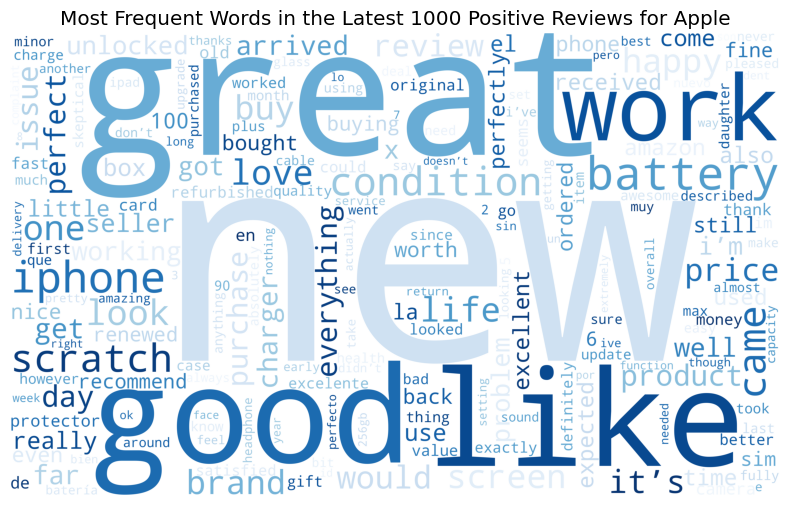

In [ ]:
# 2.4 Plot wordclouds for latest 1000 reviews for Apple
apple_pos = " ".join(apple[apple["positivity"]==1]["clean_text"][0:1000])
apple_pos_word_freq = word_freq_dict(apple_pos)
wordcloud = WordCloud(width=5000,
                      height=3000,
                      max_words=200,
                      colormap="Blues",
                      background_color="white")
wordcloud_from_frequency(apple_pos_word_freq, "Most Frequent Words in the Latest 1000 Positive Reviews for Apple")

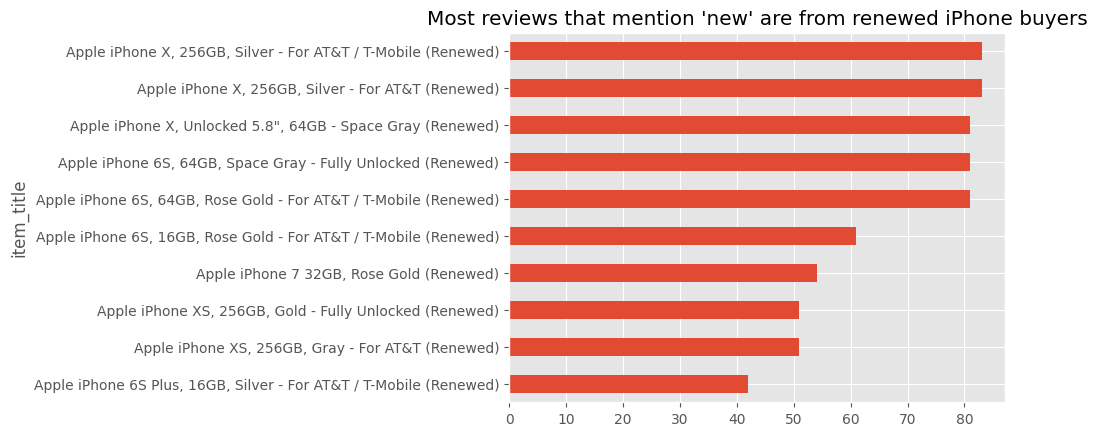

In [ ]:
apple[apple["clean_text"].apply(lambda x: "new" in x)]["item_title"].value_counts().sort_values(ascending=True).tail(10).plot(kind="barh")
plt.title("Most reviews that mention 'new' are from renewed iPhone buyers")
plt.show()

In [ ]:
apple["renewed"] = apple["item_title"].apply(lambda x: ("Renewed" in x) | ("Reburshied" in x))
print("{0: 0.1%} iPhones that were sold on Amazon are renewed/reburshied.".format(apple["renewed"].sum() / len(apple["renewed"])))

 100.0% iPhones that were sold on Amazon are renewed/reburshied.


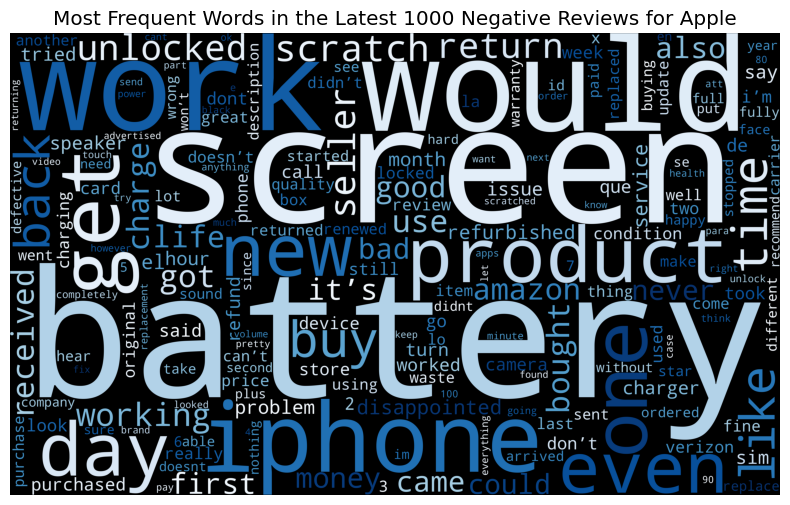

In [ ]:
apple_neg = " ".join(apple[apple["positivity"]==-1]["clean_text"][0:1000])
apple_neg_word_freq = word_freq_dict(apple_neg)
wordcloud = WordCloud(width=5000,
                      height=3000,
                      max_words=200,
                      colormap="Blues",
                      background_color="black")
wordcloud_from_frequency(apple_neg_word_freq, "Most Frequent Words in the Latest 1000 Negative Reviews for Apple")

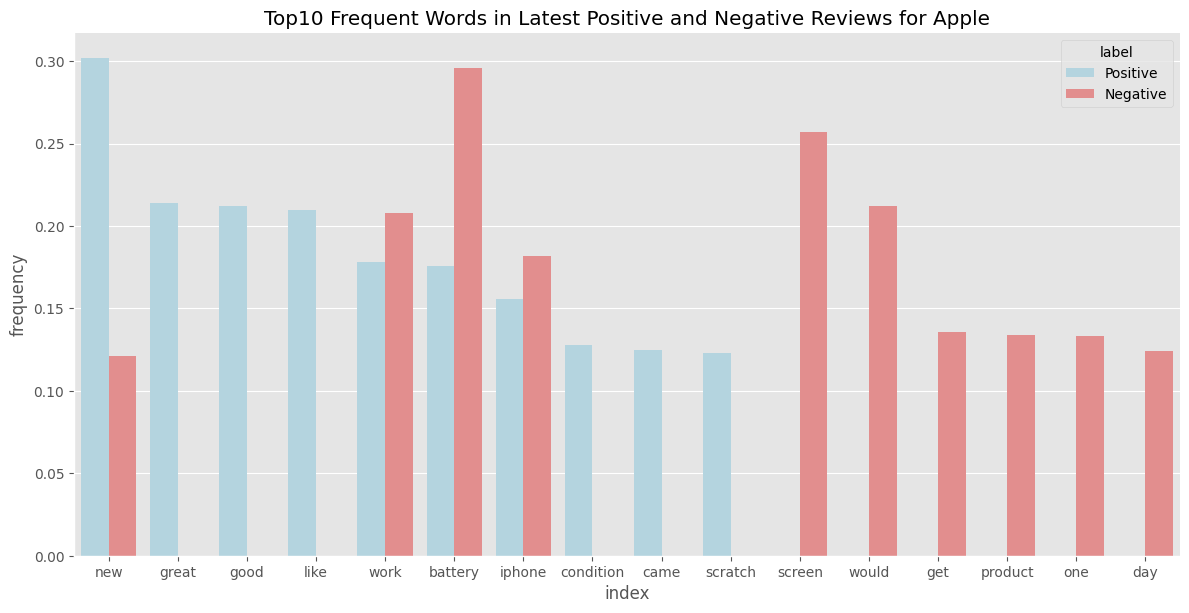

In [ ]:
topn_wordfreq_bar_both(apple_pos_word_freq, apple_neg_word_freq,
                       min(sum(apple["positivity"]==1), 1000),
                       min(sum(apple["positivity"]==-1), 1000),
                       10,
                       "Top10 Frequent Words in Latest Positive and Negative Reviews for Apple",
                       ["lightblue", "lightcoral"],
                       height=6, aspect=2)

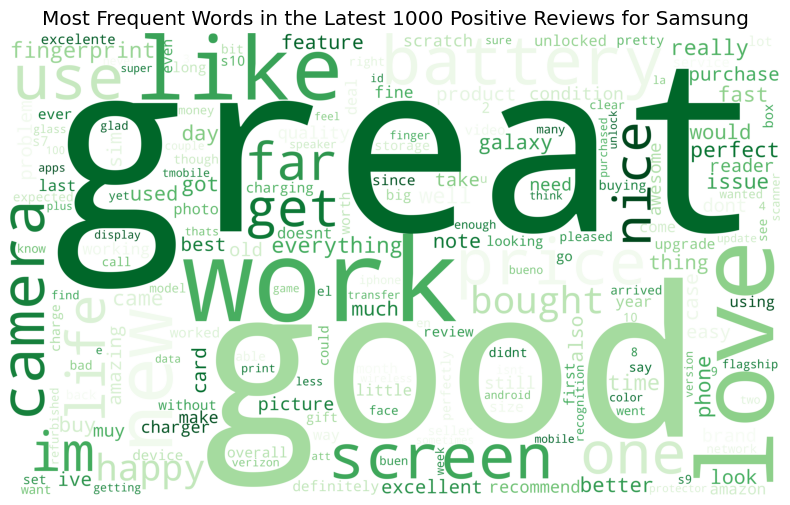

In [ ]:
# 2.5 Plot wordclouds for latest 1000 reviews for Samsung
samsung_pos = " ".join(samsung[samsung["positivity"]==1]["clean_text"][0:1000])
samsung_pos_word_freq = word_freq_dict(samsung_pos)
wordcloud = WordCloud(width=5000,
                      height=3000,
                      max_words=200,
                      colormap="Greens",
                      background_color="white")
wordcloud_from_frequency(samsung_pos_word_freq, "Most Frequent Words in the Latest 1000 Positive Reviews for Samsung")

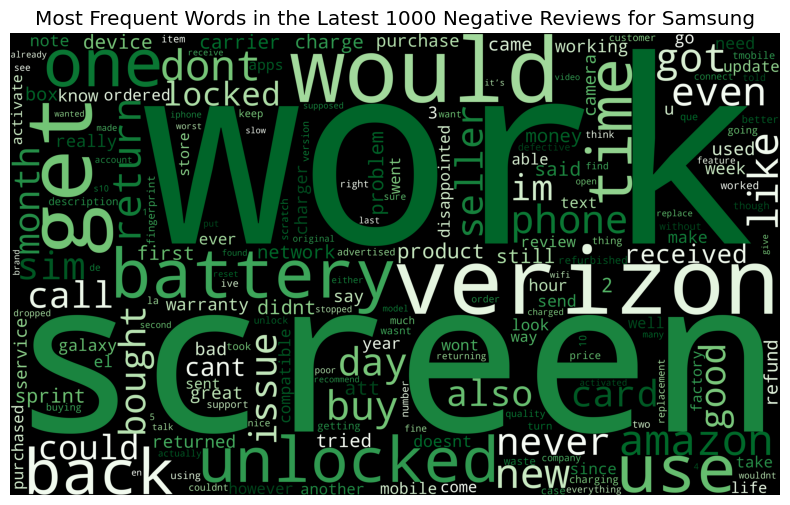

In [ ]:
samsung_neg = " ".join(samsung[samsung["positivity"]==-1]["clean_text"][0:1000])
samsung_neg_word_freq = word_freq_dict(samsung_neg)
wordcloud = WordCloud(width=5000,
                      height=3000,
                      max_words=200,
                      colormap="Greens",
                      background_color="black")
wordcloud_from_frequency(samsung_neg_word_freq, "Most Frequent Words in the Latest 1000 Negative Reviews for Samsung")

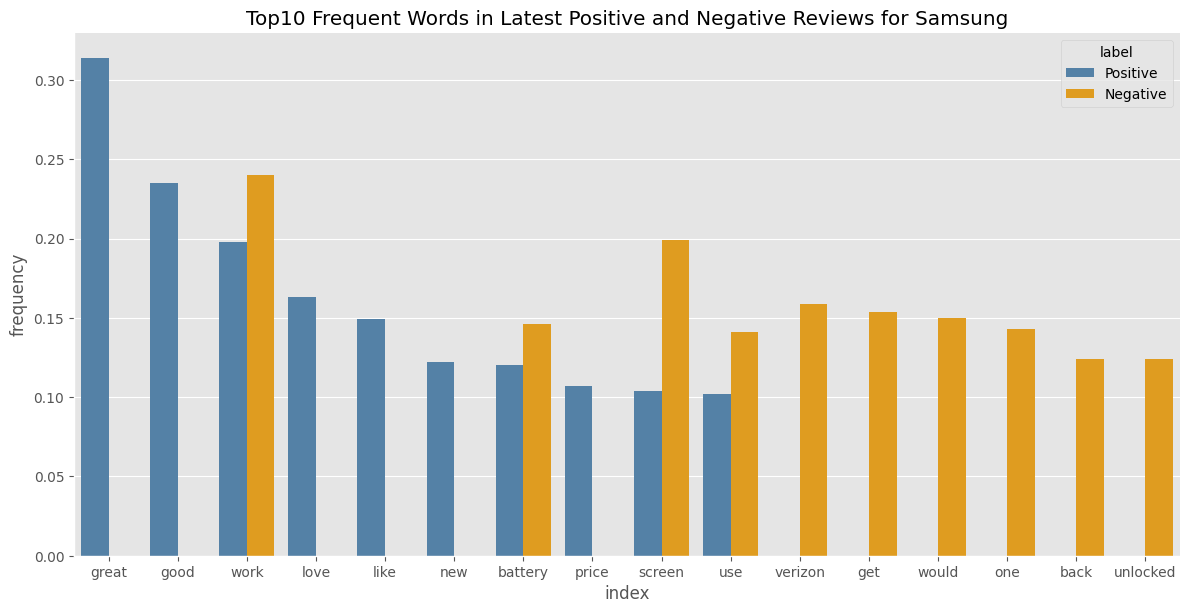

In [ ]:
topn_wordfreq_bar_both(samsung_pos_word_freq, samsung_neg_word_freq,
                       min(sum(samsung["positivity"]==1), 1000),
                       min(sum(samsung["positivity"]==-1), 1000),
                       10,
                       "Top10 Frequent Words in Latest Positive and Negative Reviews for Samsung",
                       ["steelblue", "orange"],
                       height=6, aspect=2)

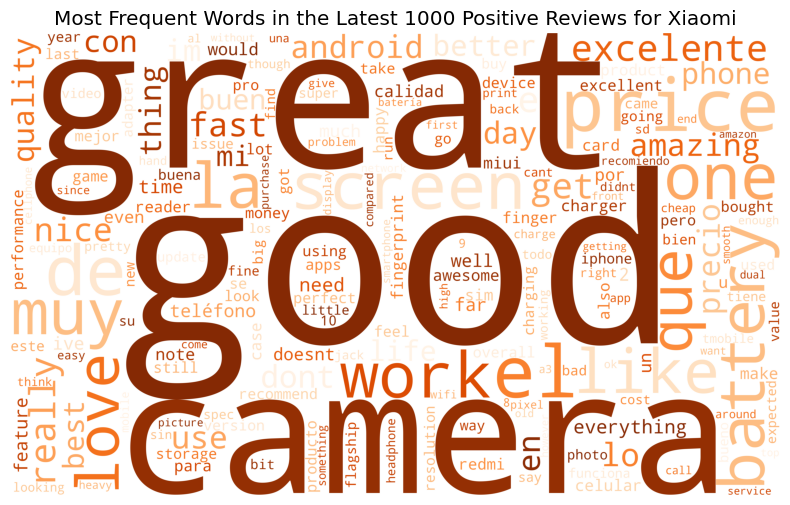

In [ ]:
# 2.6 Plot wordclouds for latest 1000 reviews for Xiaomi
xiaomi_pos = " ".join(xiaomi[xiaomi["positivity"]==1]["clean_text"][0:1000])
xiaomi_pos_word_freq = word_freq_dict(xiaomi_pos)
wordcloud = WordCloud(width=5000,
                      height=3000,
                      max_words=200,
                      colormap="Oranges",
                      background_color="white")
wordcloud_from_frequency(xiaomi_pos_word_freq, "Most Frequent Words in the Latest 1000 Positive Reviews for Xiaomi")

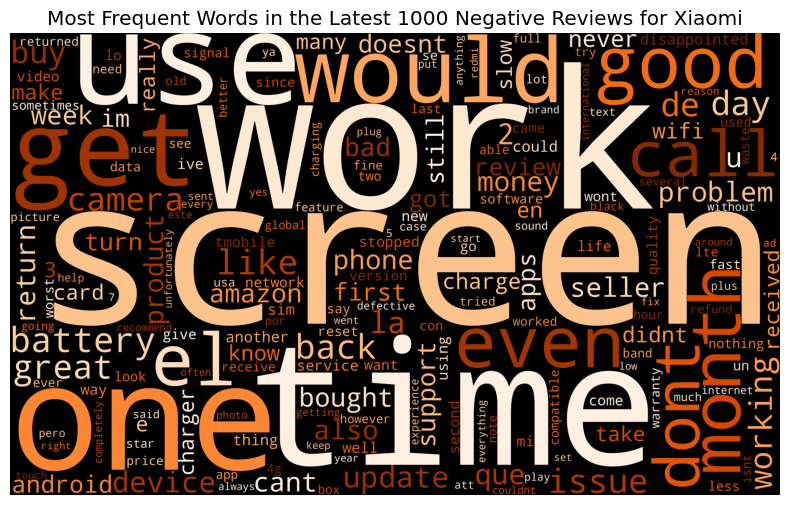

In [ ]:
xiaomi_neg = " ".join(xiaomi[xiaomi["positivity"]==-1]["clean_text"][0:1000])
xiaomi_neg_word_freq = word_freq_dict(xiaomi_neg)
wordcloud = WordCloud(width=5000,
                      height=3000,
                      max_words=200,
                      colormap="Oranges",
                      background_color="black")
wordcloud_from_frequency(xiaomi_neg_word_freq, "Most Frequent Words in the Latest 1000 Negative Reviews for Xiaomi")


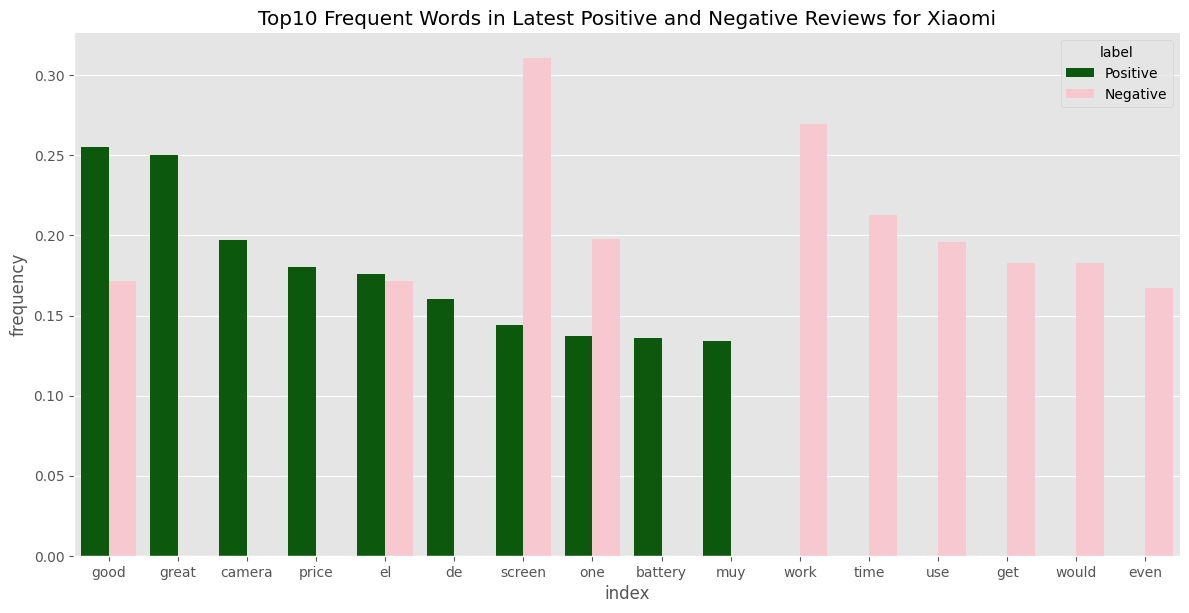

In [ ]:
topn_wordfreq_bar_both(xiaomi_pos_word_freq, xiaomi_neg_word_freq,
                       min(sum(xiaomi["positivity"]==1), 1000),
                       min(sum(xiaomi["positivity"]==-1), 1000),
                       10,
                       "Top10 Frequent Words in Latest Positive and Negative Reviews for Xiaomi",
                       ["darkgreen", "pink"],
                       height=6, aspect=2)

In [ ]:
# Step 3: Vectorization and Topic Modelling
# 3.1 Initialize TF-IDF vectorizer
import time
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=0.05, stop_words="english")

In [ ]:
# 3.2 Initalize LDA model
from sklearn.decomposition import LatentDirichletAllocation
n_topics=10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=50,
                                learning_method='online',
                                learning_offset=50.,
                                random_state=0)

In [ ]:
# 3.3 Define a function to print LDA topics
def print_topn_words(model, feature_names, topn):
    for topic_idx, topic in enumerate(model.components_):
        message = "Topic #%d: " % topic_idx
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-topn - 1:-1]])
        print(message)
    print()

In [ ]:
# 3.4 Run LDA model for Apple
t0 = time.time()
apple_tfidf = tfidf_vectorizer.fit_transform(apple["clean_text"])
apple_tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
lda.fit(apple_tfidf)
print("Below is the output from LDA model with {} topics (each includes Top10 words) for Apple.".format(n_topics))
print_topn_words(lda, apple_tfidf_feature_names, 10)
print("Done in %0.3fs." % (time.time() - t0))

Below is the output from LDA model with 10 topics (each includes Top10 words) for Apple.
Topic #0: like new look brand work came scratch battery happy buy
Topic #1: problem working day got refurbished iphone work screen time seller
Topic #2: iphone bought use buy refurbished new got purchase work day
Topic #3: charger time came work good got screen great scratch like
Topic #4: great price issue review got use day scratch battery like
Topic #5: product far good great working work new scratch buy came
Topic #6: screen scratch seller purchase happy battery new came review iphone
Topic #7: love work unlocked great bought scratch use iphone day new
Topic #8: good battery life scratch work new iphone day came great
Topic #9: condition perfect came great work scratch new iphone good battery

Done in 31.272s.


In [ ]:
# Run the model for Samsung
t0 = time.time()
samsung_tfidf = tfidf_vectorizer.fit_transform(samsung["clean_text"])
samsung_tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
lda.fit(samsung_tfidf)
print("Below is the output from LDA model with {} topics (each includes Top10 words) for Samsung.".format(n_topics))
print_topn_words(lda, samsung_tfidf_feature_names, 10)
print("Done in %0.3fs." % (time.time() - t0))

Below is the output from LDA model with 10 topics (each includes Top10 words) for Samsung.
Topic #0: card screen sim galaxy better note new work use like
Topic #1: time phone screen came got day im work like used
Topic #2: battery came life day note great camera need use used
Topic #3: use bought buy issue month screen dont got day problem
Topic #4: fast really im like great screen camera use work good
Topic #5: great product verizon got work screen issue new day use
Topic #6: love month great screen got camera new note use problem
Topic #7: new like problem screen used got great work dont came
Topic #8: good price camera great screen far use work got used
Topic #9: work great far need used dont screen use new problem

Done in 151.142s.


In [ ]:
# Run the model for Xiaomi
t0 = time.time()
xiaomi_tfidf = tfidf_vectorizer.fit_transform(xiaomi["clean_text"])
xiaomi_tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
lda.fit(xiaomi_tfidf)
print("Below is the output from LDA model with {} topics (each includes Top10 words) for Xiaomi.".format(n_topics))
print_topn_words(lda, xiaomi_tfidf_feature_names, 10)
print("Done in %0.3fs." % (time.time() - t0))

Below is the output from LDA model with 10 topics (each includes Top10 words) for Xiaomi.
Topic #0: excellent amazing fast price camera work screen quality battery thing
Topic #1: work screen day time battery issue camera great need use
Topic #2: la que lo el muy en excelente mi android use
Topic #3: love like best far im bought thing ive great price
Topic #4: excelente mi muy lo en el price que la im
Topic #5: good great price battery camera life fast work screen quality
Topic #6: money better quality feature great best camera really android price
Topic #7: el en que muy lo la excelente mi android work
Topic #8: nice use buy phone dont screen bought camera really battery
Topic #9: muy android using great ive like work use love camera

Done in 21.144s.


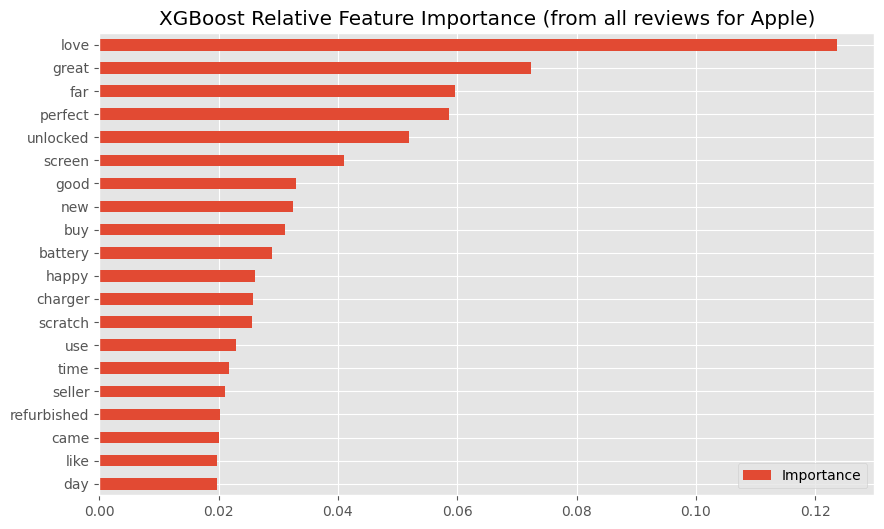

In [ ]:
# Step 4: Plot feature importance using XGBoost
# 4.1 for Apple
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Encode labels to start from 0
le = LabelEncoder()
y_encoded = le.fit_transform(apple["positivity"])

xgb_clf = xgb.XGBClassifier()
xgb_clf.fit(apple_tfidf, y_encoded)

featureImport = pd.DataFrame(xgb_clf.feature_importances_, index=apple_tfidf_feature_names)
featureImport.columns = ["Importance"]
featureImport.sort_values(["Importance"], ascending=True).tail(20).plot(kind="barh", figsize=(10, 6))
plt.title("XGBoost Relative Feature Importance (from all reviews for Apple)")
plt.show()

In [ ]:
pip install langdetect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=5c88716c37930e2657ffe98991bddfdb46cd377c77b0fcb489ced58b0818f983
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
# Step 1: Filter English reviews
# 1.1 Add language labels (This part can take ~15 minutes)
from langdetect import detect
def lang_detect(text):
    try:
        return detect(text)
    except:
        return None
import time
start_time = time.time()
reviews["lang"] = reviews["body"].apply(lang_detect)
print("It takes %s seconds for the code to finish." % (time.time() - start_time))

It takes 281.53048968315125 seconds for the code to finish.


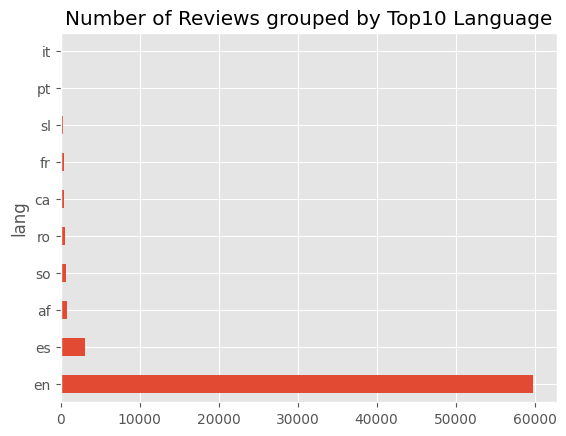

In [ ]:
# 1.2 Plot distribution of reviews into languages
reviews["lang"].value_counts()[:10].plot(kind="barh", title="Number of Reviews grouped by Top10 Language")
plt.show()

In [ ]:
# 1.3 Only take English reviews
reviews = reviews[reviews["lang"]=="en"]

In [ ]:
# Step 2: Sentiment analysis using Vader
# 2.1 Load packages
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores("The weather is nice today.")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


{'neg': 0.0, 'neu': 0.588, 'pos': 0.412, 'compound': 0.4215}

In [ ]:
# 2.2 Create sentiment score columns (It takes roughly 5 minutes)
start_time = time.time()
reviews["body"] = reviews["body"].astype("str")
reviews["sent_neg"] = reviews["body"].apply(lambda x: analyzer.polarity_scores(x)["neg"])
reviews["sent_neu"] = reviews["body"].apply(lambda x: analyzer.polarity_scores(x)["neu"])
reviews["sent_pos"] = reviews["body"].apply(lambda x: analyzer.polarity_scores(x)["pos"])
reviews["sent_comp"] = reviews["body"].apply(lambda x: analyzer.polarity_scores(x)["compound"])
print("It takes %s seconds for the code to finish." % (time.time() - start_time))

It takes 165.63583183288574 seconds for the code to finish.


In [ ]:
# 2.3 Save the datasets into csv
reviews.to_csv("reviews_with_sentiment_scores.csv")

In [ ]:
# After the steps above we will get a pre-proceessed dataset
reviews_en = pd.read_csv("/content/reviews_with_sentiment_scores.csv")

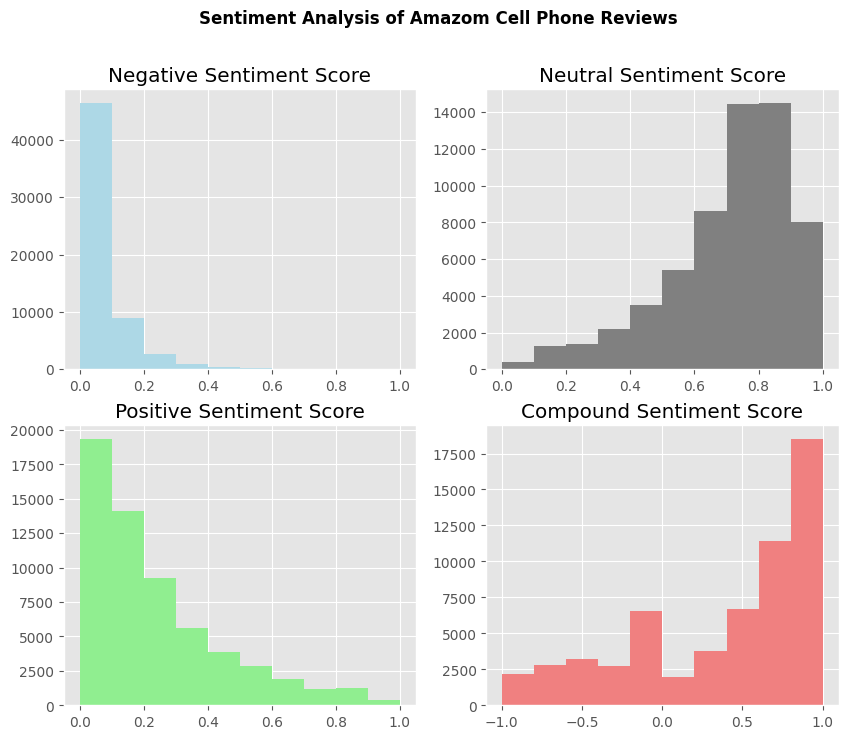

In [ ]:
# 2.4 Plot the distribution of sentiment scores
plt.figure()

plt.subplot(2, 2, 1)
reviews_en["sent_neg"].hist(figsize=(10, 8), color="lightblue")
plt.title("Negative Sentiment Score")
plt.subplot(2, 2, 2)
reviews_en["sent_neu"].hist(figsize=(10, 8), color="grey")
plt.title("Neutral Sentiment Score")
plt.subplot(2, 2, 3)
reviews_en["sent_pos"].hist(figsize=(10, 8), color="lightgreen")
plt.title("Positive Sentiment Score")
plt.subplot(2, 2, 4)
reviews_en["sent_comp"].hist(figsize=(10, 8), color="lightcoral")
plt.title("Compound Sentiment Score")

plt.suptitle('Sentiment Analysis of Amazom Cell Phone Reviews', fontsize=12, fontweight='bold');

plt.show()

The correlation coefficient between sentiment score (compound) and rating is  0.6047 with a p-value of  0.0000.


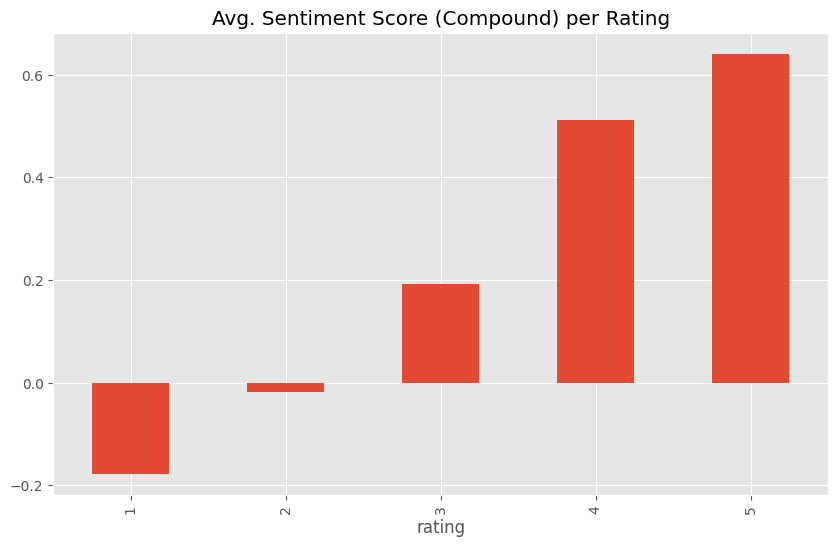

In [ ]:
# 2.5 Check the correlation between sentiment score (compound) and rating
# 2.5 Check the correlation between sentiment score (compound) and rating
import numpy as np
import scipy.stats as stats

# Make sure sent_comp is numeric
reviews_en["sent_comp"] = pd.to_numeric(reviews_en["sent_comp"], errors='coerce')

print("The correlation coefficient between sentiment score (compound) and rating is {0[0]: .4f} with a p-value of {0[1]: .4f}.".format(stats.pearsonr(reviews_en["rating"], reviews_en["sent_comp"])))

# For the plot, use numeric_only parameter
reviews_en.groupby("rating")["sent_comp"].mean().plot(kind="bar", figsize=(10, 6))
plt.title("Avg. Sentiment Score (Compound) per Rating")
plt.show()

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# VADER lexicon ko download karna (Agar pehle se nahi kiya ho toh)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError: # Corrected exception type
    nltk.download('vader_lexicon')

# --- Data Loading (Apne file names use kiye hain) ---
print("--- 1. Data Loading ---")
try:
    # Reviews aur Items files ko load karna
    # Use the actual file names for the files you uploaded
    reviews_df = pd.read_csv('20191226-reviews.csv', encoding='utf-8')
    items_df = pd.read_csv('20191226-items.csv', encoding='utf-8')
    print("✅ Data files successfully loaded.")
except FileNotFoundError:
    print("❌ Error: Files not found. Please ensure both CSV files are uploaded in Colab.")
    # It's better to exit or handle this error more gracefully in a real application
    # For this example, we'll print the error and continue,
    # which might lead to further errors if the dataframes are not loaded.
    # In a production scenario, you would likely want to exit or raise an exception.
    pass


# --- Sentiment Score Calculation (VADER) ---
print("\n--- 2. Sentiment Score Calculation ---")
# Check if reviews_df is loaded before proceeding
if 'reviews_df' in locals() and not reviews_df.empty:
    reviews_df.dropna(subset=['body'], inplace=True)
    sia = SentimentIntensityAnalyzer()

    # Sentiment scores calculate karna
    reviews_df['sentiment_scores'] = reviews_df['body'].apply(lambda x: sia.polarity_scores(x))
    reviews_df['neg'] = reviews_df['sentiment_scores'].apply(lambda x: x['neg'])
    reviews_df['neu'] = reviews_df['sentiment_scores'].apply(lambda x: x['neu'])
    reviews_df['pos'] = reviews_df['sentiment_scores'].apply(lambda x: x['pos'])
    reviews_df['compound'] = reviews_df['sentiment_scores'].apply(lambda x: x['compound'])
    print("✅ Sentiment scores (neg, neu, pos, compound) calculated.")
else:
    print("Skipping sentiment score calculation as reviews_df is not loaded.")


# --- Data Merging ---
print("\n--- 3. Data Merging ---")

# Check if both dataframes are loaded before merging
if 'reviews_df' in locals() and 'items_df' in locals() and not reviews_df.empty and not items_df.empty:
    # Items aur Reviews ko 'asin' (product ID) ke base par merge karna
    merged_df = pd.merge(reviews_df, items_df, on='asin', how='left')
    # Rename column BEFORE dropping NaN values
    merged_df.rename(columns={'title_y': 'product_name', 'title_x': 'review_title', 'rating_y': 'overall_rating', 'rating_x': 'review_rating'}, inplace=True)
    merged_df.dropna(subset=['brand', 'compound', 'product_name'], inplace=True)
    merged_df['brand'] = merged_df['brand'].str.strip() # Extra spaces hatana

    print(f"✅ DataFrames merged. Total rows for analysis: {len(merged_df)}")
else:
    print("Skipping data merging as either reviews_df or items_df is not loaded.")


# ----------------------------------------------------------------------
# --- INTERACTIVE ANALYSIS FUNCTION ---
# ----------------------------------------------------------------------

def analyze_sentiment(df, search_term, search_type='brand'):
    """
    Ek specific brand ya product ka sentiment analyze karta hai.
    search_type: 'brand' ya 'product' ho sakta hai.
    """

    if search_type == 'brand':
        # Brand name ke liye filtering (case insensitive)
        filter_col = 'brand'
        title = f"Brand: {search_term.upper()}"
    elif search_type == 'product':
        # Product name (title) ke liye filtering (case insensitive)
        filter_col = 'product_name'
        title = f"Product: {search_term}"
    else:
        print("❌ Invalid search_type. Use 'brand' or 'product'.")
        return

    # Filtering
    analysis_df = df[df[filter_col].str.contains(search_term, case=False, na=False)]

    if analysis_df.empty:
        print(f"❌ Maaf kijiye, '{search_term}' ({search_type}) ka data nahi mila.")
        return

    # Average Scores calculate karna
    avg_pos = analysis_df['pos'].mean() * 100
    avg_neg = analysis_df['neg'].mean() * 100
    avg_neu = analysis_df['neu'].mean() * 100
    avg_compound = analysis_df['compound'].mean()

    # Overall Sentiment aur Emoji decide karna
    if avg_compound >= 0.05:
        sentiment = "STRONG POSITIVE"
        emoji = "😄👍"
    elif avg_compound <= -0.05:
        sentiment = "STRONG NEGATIVE"
        emoji = "😞👎"
    else:
        sentiment = "NEUTRAL"
        emoji = "😐🤷‍♂️"

    # Results Display karna
    print("\n" + "═" * 70)
    print(f"**🔬 ANALYSIS REPORT FOR: {title}** ({len(analysis_df):,} Reviews)")
    print("═" * 70)

    print("\n📊 **AVERAGE SENTIMENT BREAKDOWN:**")
    print(f"   - Positive Review Share: {avg_pos:.2f}%")
    print(f"   - Negative Review Share: {avg_neg:.2f}%")
    print(f"   - Neutral Review Share: {avg_neu:.2f}%")

    print("\n⭐ **OVERALL SENTIMENT:**")
    print(f"   - **{sentiment}** (Avg. Compound Score: {avg_compound:.4f}) {emoji}")

    # Top 3 most positive reviews dikhana
    top_3_pos = analysis_df.sort_values(by='compound', ascending=False).head(3)
    print("\n✅ **TOP 3 MOST POSITIVE REVIEWS:**")
    for i, review in enumerate(top_3_pos['body']):
        print(f"   {i+1}. {review[:80]}... (Score: {top_3_pos.iloc[i]['compound']:.3f})")

    # Top 3 most negative reviews dikhana
    top_3_neg = analysis_df.sort_values(by='compound', ascending=True).head(3)
    print("\n❌ **TOP 3 MOST NEGATIVE REVIEWS:**")
    for i, review in enumerate(top_3_neg['body']):
        print(f"   {i+1}. {review[:80]}... (Score: {top_3_neg.iloc[i]['compound']:.3f})")

    print("═" * 70)

# ----------------------------------------------------------------------
# --- INTERACTIVE USER INPUT ---
# ----------------------------------------------------------------------

print("\n\n--- 4. INTERACTIVE SENTIMENT CHECKER ---")

# Check if merged_df is loaded before starting interactive analysis
if 'merged_df' in locals() and not merged_df.empty:
    while True:
        print("\n--- Choose Analysis Type ---")
        print("1: Brand Analysis (e.g., Samsung)")
        print("2: Specific Product Analysis (e.g., Samsung Galaxy S9)")
        print("0: Exit")
        choice = input("Enter your choice (1, 2, or 0): ")

        if choice == '1':
            # Brand-wise analysis
            search_term = input("🔎 Kripya Brand ka naam daaliye (e.g., Apple, Motorola): ")
            if search_term:
                analyze_sentiment(merged_df, search_term, search_type='brand')

        elif choice == '2':
            # Product-wise analysis
            search_term = input("🔎 Kripya Phone ka pura naam ya hissa daaliye (e.g., Moto G7 Play): ")
            if search_term:
                # Note: Isme Product ka naam poora ya uska important part likhna hoga.
                analyze_sentiment(merged_df, search_term, search_type='product')

        elif choice == '0':
            print("Exiting Interactive Checker. Thank you!")
            break
        else:
            print("Invalid choice. Please enter 1, 2, or 0.")
else:
    print("Skipping interactive sentiment checker as merged_df is not loaded.")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


--- 1. Data Loading ---
✅ Data files successfully loaded.

--- 2. Sentiment Score Calculation ---
✅ Sentiment scores (neg, neu, pos, compound) calculated.

--- 3. Data Merging ---
✅ DataFrames merged. Total rows for analysis: 67760


--- 4. INTERACTIVE SENTIMENT CHECKER ---

--- Choose Analysis Type ---
1: Brand Analysis (e.g., Samsung)
2: Specific Product Analysis (e.g., Samsung Galaxy S9)
0: Exit
Enter your choice (1, 2, or 0): 1
🔎 Kripya Brand ka naam daaliye (e.g., Apple, Motorola): Apple

══════════════════════════════════════════════════════════════════════
**🔬 ANALYSIS REPORT FOR: Brand: APPLE** (5,145 Reviews)
══════════════════════════════════════════════════════════════════════

📊 **AVERAGE SENTIMENT BREAKDOWN:**
   - Positive Review Share: 23.46%
   - Negative Review Share: 6.74%
   - Neutral Review Share: 69.70%

⭐ **OVERALL SENTIMENT:**
   - **STRONG POSITIVE** (Avg. Compound Score: 0.2818) 😄👍

✅ **TOP 3 MOST POSITIVE REVIEWS:**
   1. First off, I would like to provide my 